# ✈️ Flight Delay Prediction — EDA
### Data Bootcamp Final Project

**Dataset:** 2015 Flight Delays and Cancellations (Kaggle / USDOT)  
**Notebook scope:** Data loading, preprocessing, and exploratory data analysis

---

## 📋 Table of Contents
1. [Introduction](#introduction)
2. [Data Loading & Description](#data-loading)
3. [Data Preprocessing](#preprocessing)
4. [Exploratory Data Analysis (EDA)](#eda)


---
## 1. Introduction <a id='introduction'></a>
Flight delays affect millions of travelers every year, causing missed connections, disrupted plans, and significant economic costs for both passengers and airlines. The 2015 USDOT dataset contains ~5.8 million domestic U.S. flight records with detailed information on airlines, airports, scheduled times, delay causes, and cancellations.
 
**Predictive Task:** Given information available *before a flight departs* — airline, origin airport, destination, scheduled departure time, month, day of week, etc. — can we predict whether it will arrive more than 15 minutes late?
 
**Why this matters:** Accurate pre-departure delay prediction helps travelers make informed decisions, and enables airlines to proactively allocate ground resources to highest-risk flights.
 
**Summary Findings:** We trained and compared **five binary classifiers** on 200,000 sampled flights, and extended the analysis to **multi-class delay prediction** (On Time / Short Delay / Long Delay / Cancelled) and **profit curve optimization**. A central challenge was class imbalance (82.4% on-time vs. 17.6% delayed), addressed via `class_weight='balanced'` and downsampling. **Random Forest** was the best binary classifier overall (Recall = **61.9%**, F1 = **0.354**, ROC-AUC = **0.653**). For multi-class prediction, a tuned Random Forest achieved **80.6% accuracy** using GridSearchCV. The most important predictive feature was **departure hour** (importance = 0.361) — evening flights accumulate cascading delays throughout the day. Targeting the top 20% highest-risk flights captures **33.9% of all delays**, a **1.69× lift** over random selection, with a simulated maximum profit of **$413,620**.
 


---
## 2. Data Loading & Description <a id='data-loading'></a>

**Data Source:** [Kaggle - 2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)  
The dataset contains three CSV files:
- `flights.csv` — ~5.8M flight records with delay information
- `airlines.csv` — airline IATA code to full name mapping
- `airports.csv` — airport IATA code to city/state/lat/lon mapping

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, roc_auc_score,
    RocCurveDisplay, precision_recall_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────────
# Make sure flights.csv, airlines.csv, airports.csv are in the same folder as this notebook
flights  = pd.read_csv('Data/flights.csv',  low_memory=False)
airlines = pd.read_csv('Data/airlines.csv')
airports = pd.read_csv('Data/airports.csv')

print(f'flights shape:  {flights.shape}')
print(f'airlines shape: {airlines.shape}')
print(f'airports shape: {airports.shape}')

flights shape:  (5819079, 31)
airlines shape: (14, 2)
airports shape: (322, 7)


In [3]:
flights.head(3)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [5]:
flights.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


---
## 3. Data Preprocessing <a id='preprocessing'></a>

Key steps:
1. **Create binary target FIRST** — derive `DELAYED` from `ARRIVAL_DELAY` before dropping any columns
2. **Drop data-leakage columns** — remove anything only known after the flight lands
3. **Handle missing values** — rows with missing target or key features are dropped
4. **Sample** — use 200k rows for manageable runtime

In [6]:
# ── 3.1 Create binary target BEFORE dropping ARRIVAL_DELAY ───────────────────
# FAA standard: a flight is 'delayed' if it arrives more than 15 minutes late
# CANCELLED flights have NaN in ARRIVAL_DELAY — we exclude them
flights['DELAYED'] = (flights['ARRIVAL_DELAY'] > 15).astype('Int64')  # Int64 handles NaN

print('Class distribution (full dataset):')
print(flights['DELAYED'].value_counts(dropna=True, normalize=True).round(3))

Class distribution (full dataset):
DELAYED
0    0.824
1    0.176
Name: proportion, dtype: Float64


In [7]:
# ── 3.2 Drop post-flight leakage columns ─────────────────────────────────────
# These columns are only known AFTER the flight — using them would be cheating!
drop_cols = [
    'YEAR',                   # constant (all 2015), no predictive value
    'FLIGHT_NUMBER',          # flight ID, not a meaningful feature
    'TAIL_NUMBER',            # plane ID, too many unique values
    'DEPARTURE_TIME',         # actual departure — not known pre-flight
    'DEPARTURE_DELAY',        # measured at departure gate — slight leakage
    'TAXI_OUT',               # post-departure
    'WHEELS_OFF',             # post-departure
    'ELAPSED_TIME',           # post-flight
    'AIR_TIME',               # post-flight
    'WHEELS_ON',              # post-flight
    'TAXI_IN',                # post-flight
    'SCHEDULED_ARRIVAL',      # derivable from SCHEDULED_DEPARTURE + SCHEDULED_TIME
    'ARRIVAL_TIME',           # post-flight
    'ARRIVAL_DELAY',          # this IS our target — already used above
    'DIVERTED',               # post-flight outcome
    'CANCELLED',              # post-flight outcome
    'CANCELLATION_REASON',    # post-flight outcome
    'AIR_SYSTEM_DELAY',       # post-flight breakdown
    'SECURITY_DELAY',         # post-flight breakdown
    'AIRLINE_DELAY',          # post-flight breakdown
    'LATE_AIRCRAFT_DELAY',    # post-flight breakdown
    'WEATHER_DELAY',          # post-flight breakdown
]

# Only drop columns that actually exist (safe against version differences)
drop_cols = [c for c in drop_cols if c in flights.columns]
df = flights.drop(columns=drop_cols).copy()

print('Remaining columns:', df.columns.tolist())

Remaining columns: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE', 'DELAYED']


In [8]:
# ── 3.3 Handle missing values ─────────────────────────────────────────────────
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0])

# Drop rows where target is missing (cancelled flights have no ARRIVAL_DELAY)
df = df.dropna(subset=['DELAYED'])
# Drop rows missing key pre-flight features
df = df.dropna(subset=['SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE',
                        'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'])
df = df.reset_index(drop=True)
print(f'\nRows after dropping NA: {len(df):,}')

Missing values per column:
SCHEDULED_TIME    6
dtype: int64

Rows after dropping NA: 5,819,073


In [9]:
# ── 3.4 Derive HOUR feature from SCHEDULED_DEPARTURE ─────────────────────────
# SCHEDULED_DEPARTURE is stored as HHMM integer e.g. 1530 = 15:30
df['HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).astype(int)

print('HOUR sample values:', df['HOUR'].unique()[:10])

HOUR sample values: [0 1 2 3 4 5 6 7 8 9]


In [10]:
# ── 3.5 Sample for manageable runtime (~200k rows) ────────────────────────────
df = df.sample(n=min(200_000, len(df)), random_state=SEED).reset_index(drop=True)
# Convert DELAYED back to plain int after sampling
df['DELAYED'] = df['DELAYED'].astype(int)
print(f'Working dataset size: {len(df):,}')
print(f'Delay rate: {df["DELAYED"].mean():.1%}')

Working dataset size: 200,000
Delay rate: 17.6%


---
## 4. Exploratory Data Analysis (EDA) <a id='eda'></a>

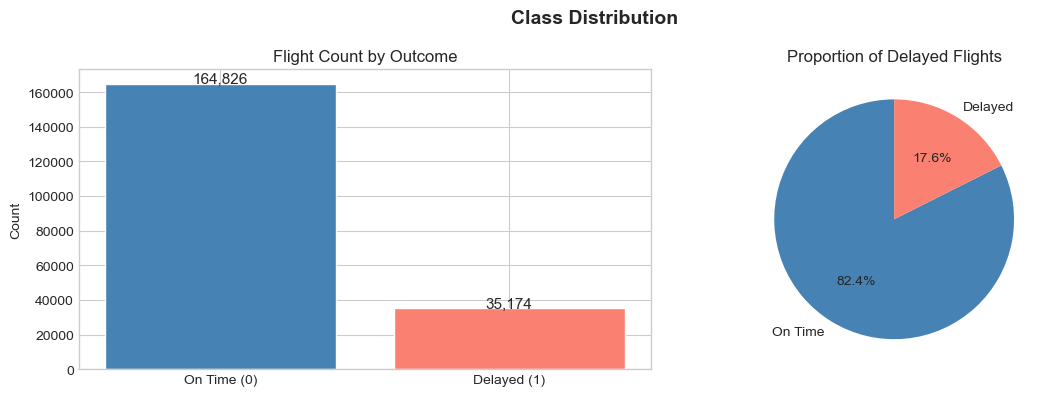

In [11]:
# ── 4.1 Class distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['DELAYED'].value_counts().sort_index()
axes[0].bar(['On Time (0)', 'Delayed (1)'], counts.values,
            color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Flight Count by Outcome')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['On Time', 'Delayed'],
            autopct='%1.1f%%', colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Proportion of Delayed Flights')

plt.suptitle('Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

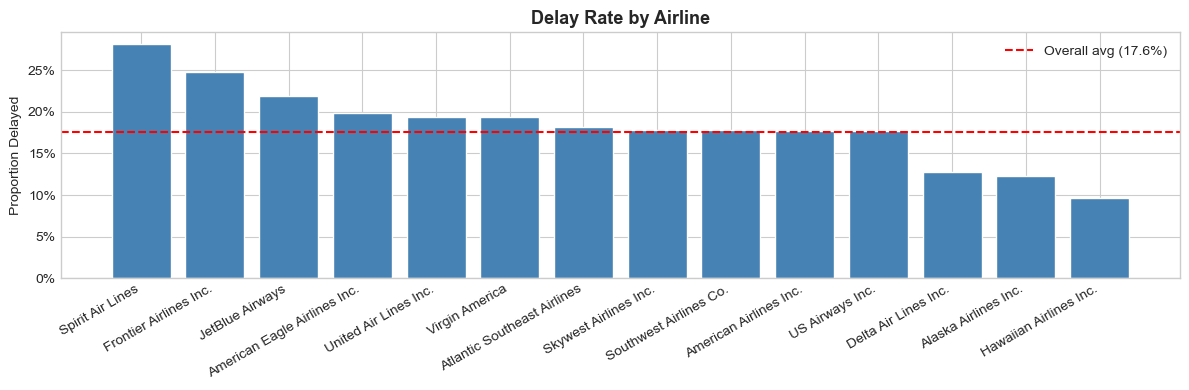

In [12]:
# ── 4.2 Delay rate by airline (with full name) ────────────────────────────────
airline_delay = (df.groupby('AIRLINE')['DELAYED']
                   .mean()
                   .sort_values(ascending=False)
                   .reset_index())
# airline_delay columns: ['AIRLINE', 'DELAYED']

# airlines.csv has columns IATA_CODE and AIRLINE — rename before merging to avoid conflict
airlines_clean = airlines.rename(columns={'IATA_CODE': 'CODE', 'AIRLINE': 'AIRLINE_NAME'})
airline_delay = airline_delay.merge(airlines_clean, left_on='AIRLINE', right_on='CODE', how='left')
# Use full name if available, otherwise fall back to IATA code
labels = airline_delay['AIRLINE_NAME'].fillna(airline_delay['AIRLINE'])

plt.figure(figsize=(12, 4))
plt.bar(labels, airline_delay['DELAYED'], color='steelblue', edgecolor='white')
plt.axhline(df['DELAYED'].mean(), color='red', linestyle='--',
            label=f'Overall avg ({df["DELAYED"].mean():.1%})')
plt.title('Delay Rate by Airline', fontsize=13, fontweight='bold')
plt.ylabel('Proportion Delayed')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

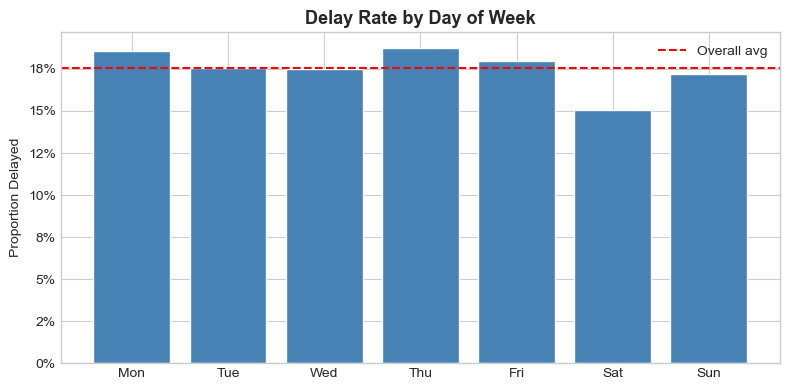

In [13]:
# ── 4.3 Delay rate by day of week ─────────────────────────────────────────────
day_names = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
day_delay = df.groupby('DAY_OF_WEEK')['DELAYED'].mean()

plt.figure(figsize=(8, 4))
plt.bar([day_names[d] for d in day_delay.index], day_delay.values,
        color='steelblue', edgecolor='white')
plt.axhline(df['DELAYED'].mean(), color='red', linestyle='--', label='Overall avg')
plt.title('Delay Rate by Day of Week', fontsize=13, fontweight='bold')
plt.ylabel('Proportion Delayed')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

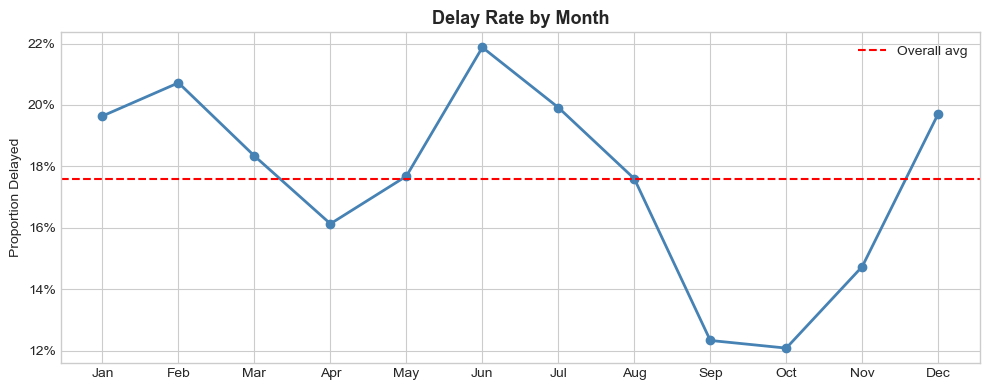

In [14]:
# ── 4.4 Delay rate by month ───────────────────────────────────────────────────
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_delay = df.groupby('MONTH')['DELAYED'].mean()

plt.figure(figsize=(10, 4))
plt.plot([month_names[m] for m in month_delay.index], month_delay.values,
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.axhline(df['DELAYED'].mean(), color='red', linestyle='--', label='Overall avg')
plt.title('Delay Rate by Month', fontsize=13, fontweight='bold')
plt.ylabel('Proportion Delayed')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

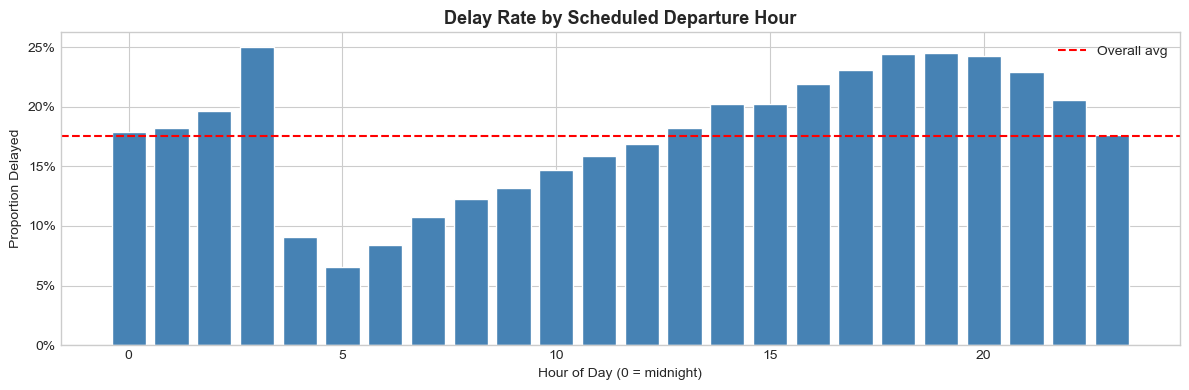

Observation: Flights later in the day have higher delay rates — cascading delays accumulate.


In [15]:
# ── 4.5 Delay rate by scheduled departure hour ────────────────────────────────
hour_delay = df.groupby('HOUR')['DELAYED'].mean()

plt.figure(figsize=(12, 4))
plt.bar(hour_delay.index, hour_delay.values, color='steelblue', edgecolor='white')
plt.axhline(df['DELAYED'].mean(), color='red', linestyle='--', label='Overall avg')
plt.title('Delay Rate by Scheduled Departure Hour', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day (0 = midnight)')
plt.ylabel('Proportion Delayed')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()
print('Observation: Flights later in the day have higher delay rates — cascading delays accumulate.')

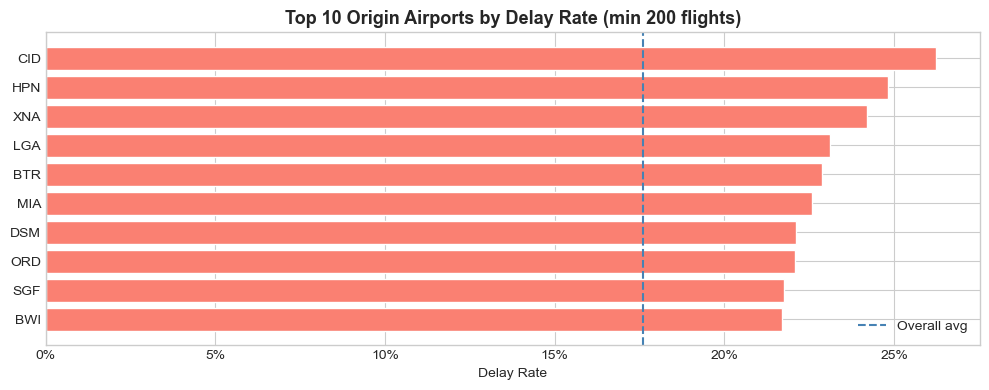

In [16]:
# ── 4.6 Top 10 origin airports by delay rate ──────────────────────────────────
airport_delay = (df.groupby('ORIGIN_AIRPORT')
                   .agg(delay_rate=('DELAYED', 'mean'), count=('DELAYED', 'count'))
                   .query('count >= 200')   # at least 200 flights to be meaningful
                   .sort_values('delay_rate', ascending=False)
                   .head(10))

plt.figure(figsize=(10, 4))
plt.barh(airport_delay.index[::-1], airport_delay['delay_rate'][::-1],
         color='salmon', edgecolor='white')
plt.axvline(df['DELAYED'].mean(), color='steelblue', linestyle='--', label='Overall avg')
plt.title('Top 10 Origin Airports by Delay Rate (min 200 flights)', fontsize=13, fontweight='bold')
plt.xlabel('Delay Rate')
plt.legend()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

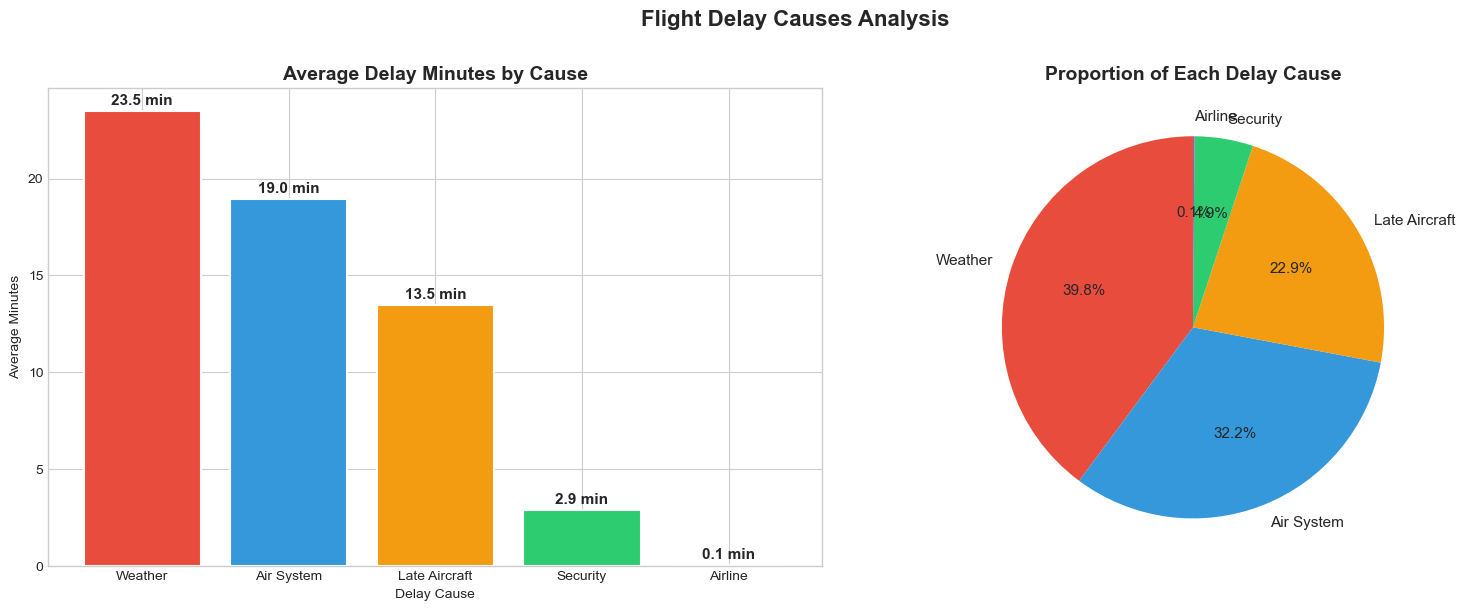

Average delay minutes by cause:
  Weather             : 23.5 min
  Air System          : 19.0 min
  Late Aircraft       : 13.5 min
  Security            : 2.9 min
  Airline             : 0.1 min


In [ ]:
# ── EDA Extension 1: Delay Cause Analysis ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


delay_causes = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
                'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
cause_labels = ['Late Aircraft', 'Airline', 'Air System', 'Weather', 'Security']
cause_colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6']

delayed_flights = flights[flights[delay_causes].notna().any(axis=1)].copy()
delayed_flights[delay_causes] = delayed_flights[delay_causes].fillna(0)


cause_means = delayed_flights[delay_causes].mean()
cause_means.index = cause_labels
cause_means = cause_means.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


bars = axes[0].bar(cause_means.index, cause_means.values,
                   color=cause_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cause_means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f} min', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Average Delay Minutes by Cause', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delay Cause')
axes[0].set_ylabel('Average Minutes')

# Pie chart
axes[1].pie(cause_means.values, labels=cause_means.index, autopct='%1.1f%%',
            colors=cause_colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proportion of Each Delay Cause', fontsize=14, fontweight='bold')

plt.suptitle('Flight Delay Causes Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Average delay minutes by cause:")
for label, val in zip(cause_means.index, cause_means.values):
    print(f"  {label:20s}: {val:.1f} min")

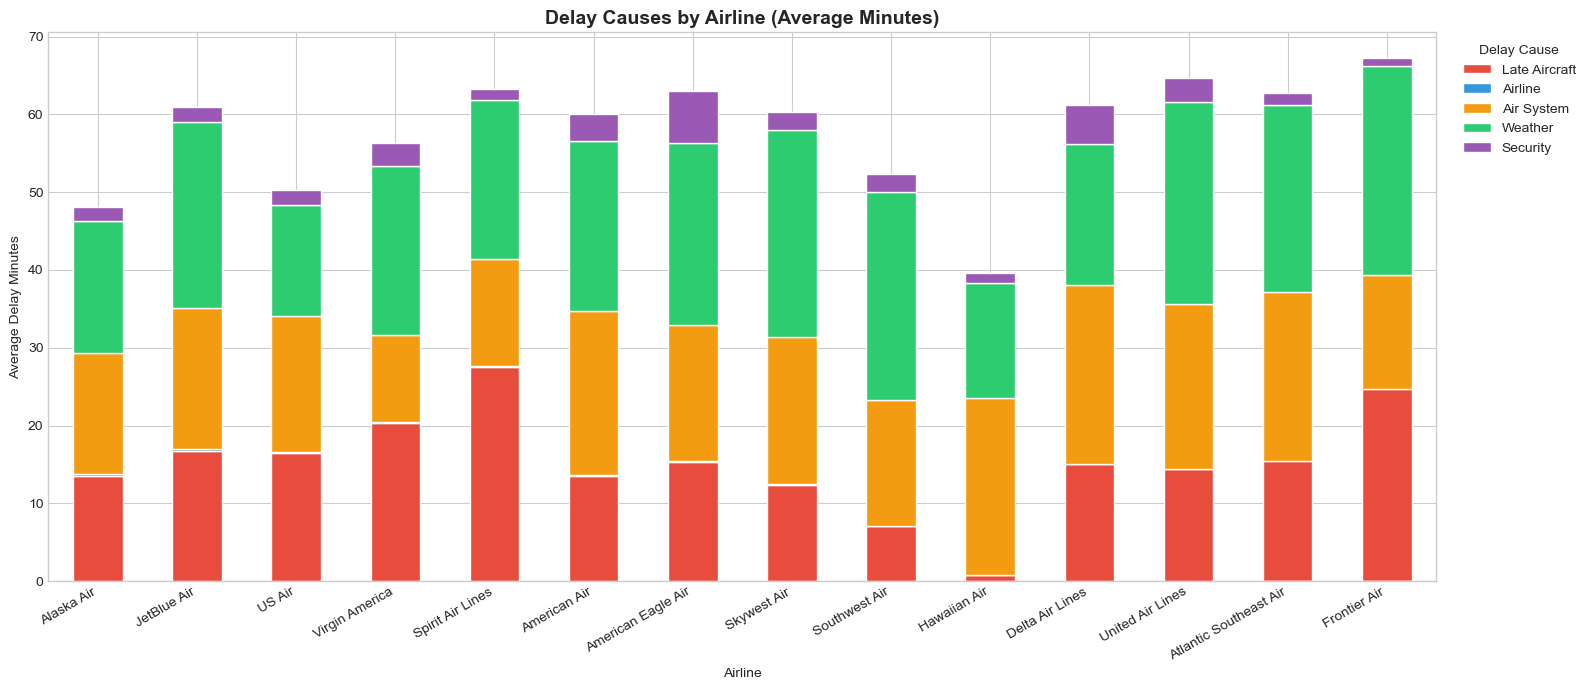

In [ ]:
# ── EDA Extension 2: Delay Cause by Airline ───────────────────────────────────

delay_causes = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
cause_labels = ['Late Aircraft', 'Airline', 'Air System', 'Weather', 'Security']
cause_colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6']

delayed_flights = flights[flights[delay_causes].notna().any(axis=1)].copy()
delayed_flights[delay_causes] = delayed_flights[delay_causes].fillna(0)


airline_cause = delayed_flights.groupby('AIRLINE')[delay_causes].mean()
airline_cause.columns = cause_labels


airline_names = dict(zip(airlines['IATA_CODE'], airlines['AIRLINE']))
airline_cause.index = [airline_names.get(i, i) for i in airline_cause.index]


airline_cause.index = (airline_cause.index
                       .str.replace(' Inc.', '', regex=False)
                       .str.replace(' Co.', '', regex=False)
                       .str.replace(' Airlines', ' Air', regex=False)
                       .str.replace(' Airways', ' Air', regex=False))

airline_cause = airline_cause.sort_values('Airline', ascending=False)

airline_cause.plot(
    kind='bar', stacked=True, figsize=(16, 7),
    color=cause_colors, edgecolor='white'
)
plt.title('Delay Causes by Airline (Average Minutes)', fontsize=14, fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Average Delay Minutes')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Delay Cause', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

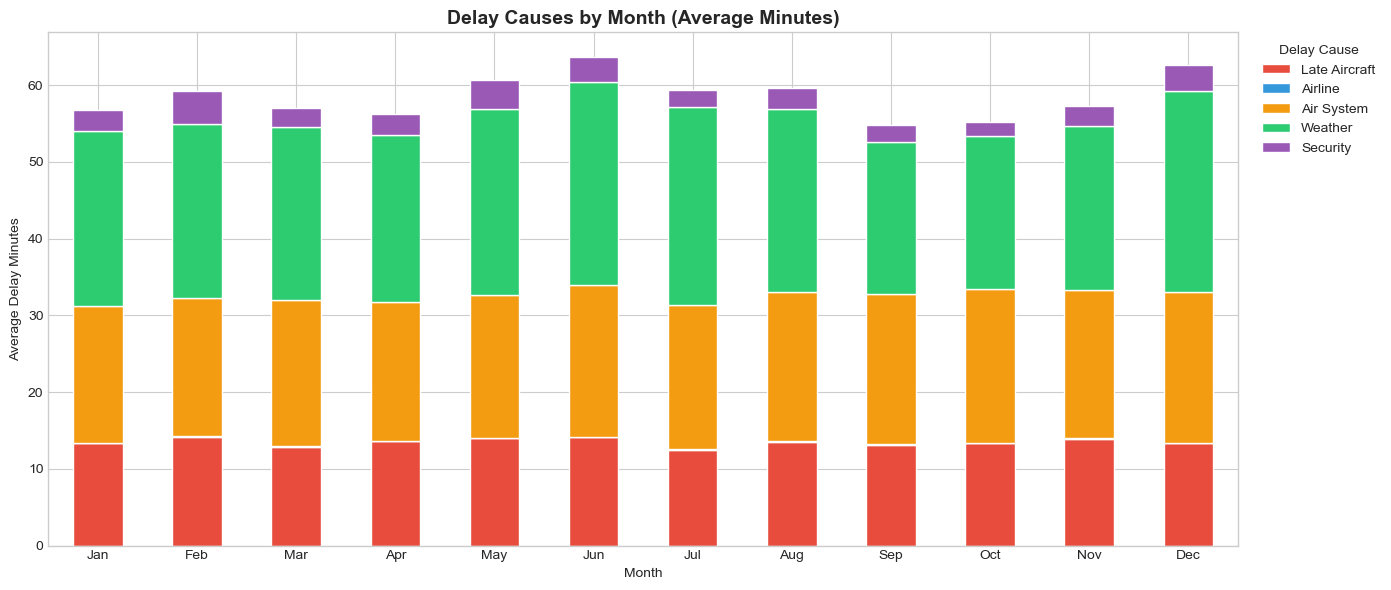

Key observation:
- Weather delays peak in winter (Jan/Feb) and summer storms (Jun/Jul)
- Late Aircraft delays are consistently the largest cause year-round


In [19]:
# ── EDA Extension 3: Delay Cause by Month ─────────────────────────────────────

delay_causes = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
cause_labels = ['Late Aircraft', 'Airline', 'Air System', 'Weather', 'Security']
cause_colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71', '#9b59b6']

delayed_flights = flights[flights[delay_causes].notna().any(axis=1)].copy()
delayed_flights[delay_causes] = delayed_flights[delay_causes].fillna(0)

month_cause = delayed_flights.groupby('MONTH')[delay_causes].mean()
month_cause.columns = cause_labels
month_cause.index = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

month_cause.plot(
    kind='bar', stacked=True, figsize=(14, 6),
    color=cause_colors, edgecolor='white'
)
plt.title('Delay Causes by Month (Average Minutes)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Delay Minutes')
plt.xticks(rotation=0)
plt.legend(title='Delay Cause', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print("Key observation:")
print("- Weather delays peak in winter (Jan/Feb) and summer storms (Jun/Jul)")
print("- Late Aircraft delays are consistently the largest cause year-round")

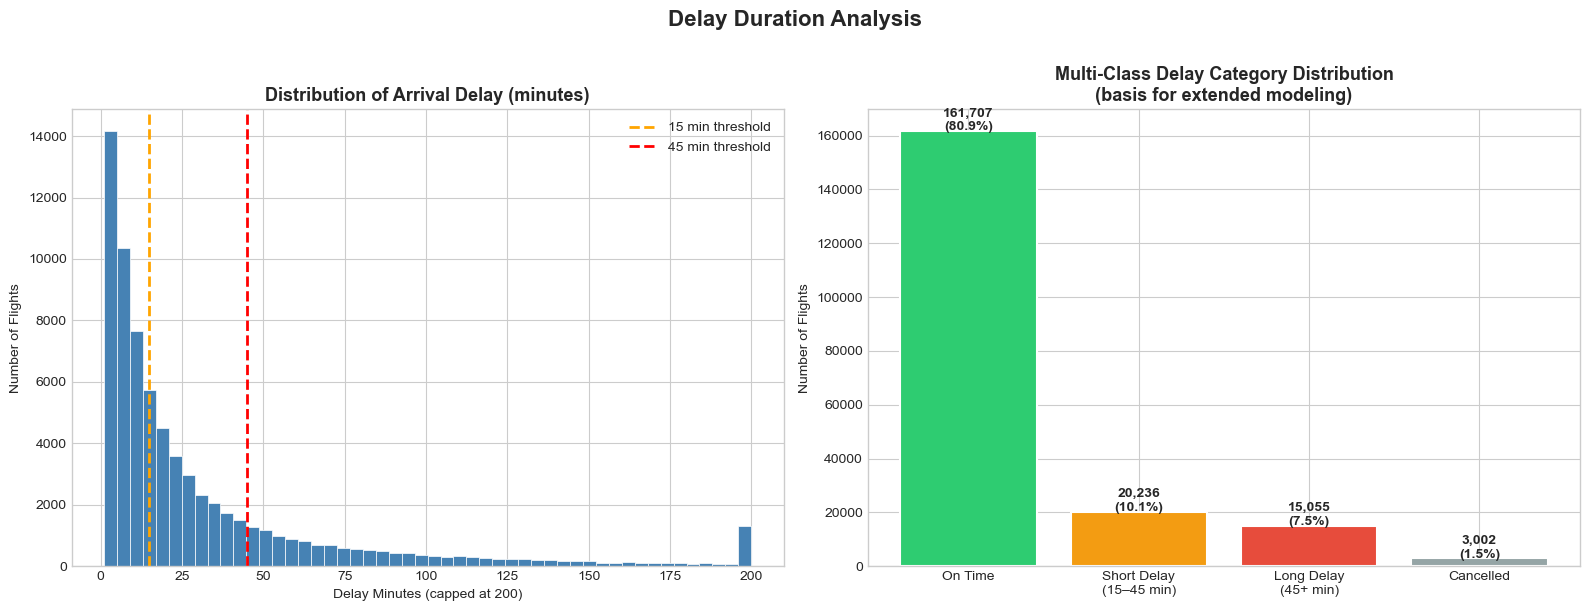


Delay category counts:
  On Time                            : 161,707 (80.9%)
  Short Delay (15–45 min)            : 20,236 (10.1%)
  Long Delay (45+ min)               : 15,055 (7.5%)
  Cancelled                          :  3,002 (1.5%)


In [ ]:
# ── EDA Extension 4: Delay Duration Distribution ──────────────────────────────


sample = flights.sample(n=200000, random_state=42).copy()
sample['ARRIVAL_DELAY'] = sample['ARRIVAL_DELAY'].fillna(0)

actual_delays = sample[
    (sample['ARRIVAL_DELAY'] > 0) & 
    (sample['CANCELLED'] == 0)
]['ARRIVAL_DELAY']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].hist(actual_delays.clip(upper=200), bins=50,
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=15, color='orange', linestyle='--', 
                linewidth=2, label='15 min threshold')
axes[0].axvline(x=45, color='red', linestyle='--', 
                linewidth=2, label='45 min threshold')
axes[0].set_title('Distribution of Arrival Delay (minutes)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delay Minutes (capped at 200)')
axes[0].set_ylabel('Number of Flights')
axes[0].legend()


def multiclass_label(delay, cancelled):
    if cancelled == 1:
        return 'Cancelled'
    elif delay <= 15:
        return 'On Time'
    elif delay <= 45:
        return 'Short Delay\n(15–45 min)'
    else:
        return 'Long Delay\n(45+ min)'

sample['DELAY_CATEGORY'] = sample.apply(
    lambda r: multiclass_label(r['ARRIVAL_DELAY'], r['CANCELLED']), axis=1
)

cat_order = ['On Time', 'Short Delay\n(15–45 min)', 'Long Delay\n(45+ min)', 'Cancelled']
cat_counts = sample['DELAY_CATEGORY'].value_counts().reindex(cat_order)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']

bars = axes[1].bar(cat_counts.index, cat_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cat_counts.values):
    pct = val / len(sample) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}\n({pct:.1f}%)', ha='center', 
                fontsize=10, fontweight='bold')
axes[1].set_title('Multi-Class Delay Category Distribution\n(basis for extended modeling)',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Flights')

plt.suptitle('Delay Duration Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nDelay category counts:")
for cat, cnt in cat_counts.items():
    print(f"  {cat.replace(chr(10),' '):35s}: {cnt:6,} ({cnt/len(sample)*100:.1f}%)")

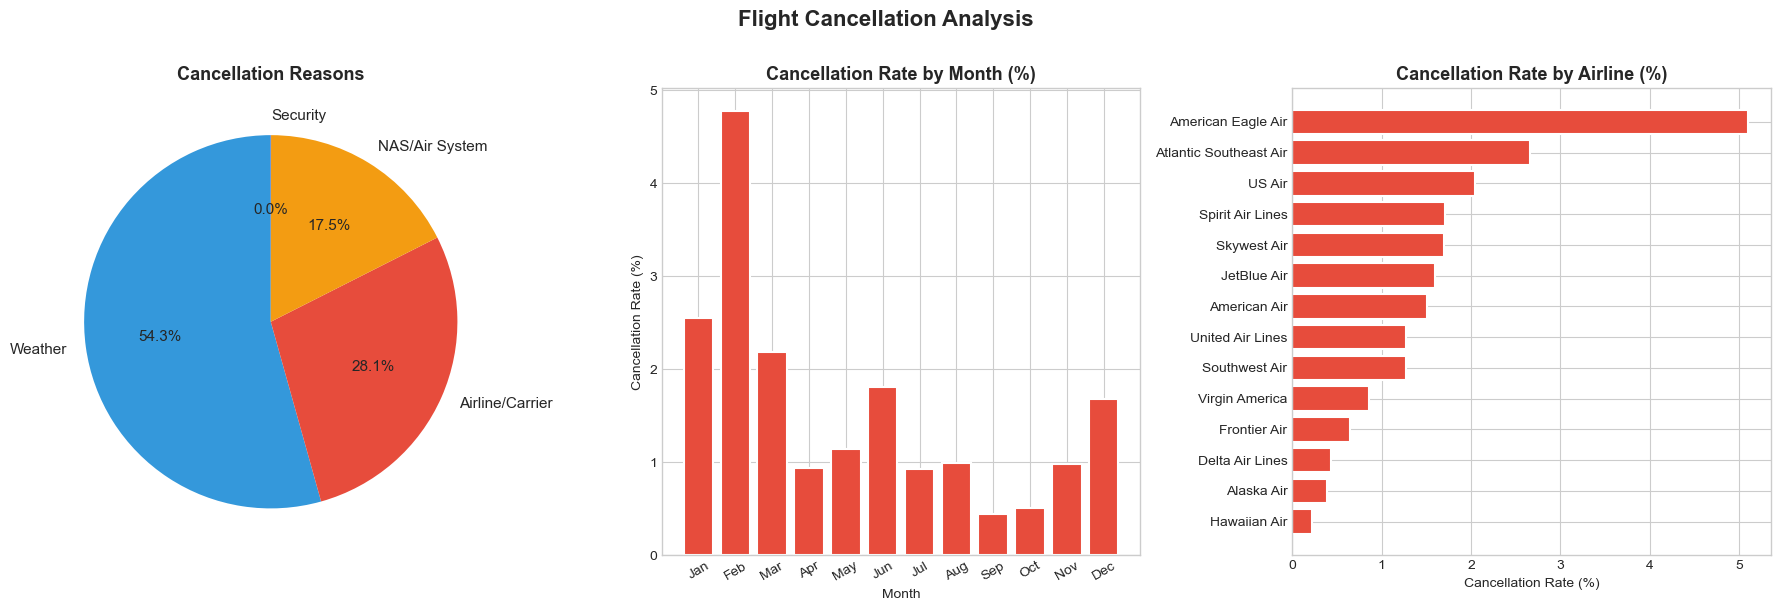


Total cancelled flights: 89,884 (1.5%)


In [21]:
# ── EDA Extension 5: Cancellation Analysis ────────────────────────────────────

cancelled = flights[flights['CANCELLED'] == 1].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 5.1 Cancellation reason distribution
cancel_reason_map = {
    'A': 'Airline/Carrier',
    'B': 'Weather',
    'C': 'NAS/Air System',
    'D': 'Security'
}
cancel_counts = (cancelled['CANCELLATION_REASON']
                 .map(cancel_reason_map)
                 .value_counts())

axes[0].pie(cancel_counts.values, labels=cancel_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'],
            textprops={'fontsize': 11})
axes[0].set_title('Cancellation Reasons', fontsize=13, fontweight='bold')

# 5.2 Cancellation rate by month
monthly_cancel = flights.groupby('MONTH').agg(
    total=('CANCELLED', 'count'),
    cancelled=('CANCELLED', 'sum')
).reset_index()
monthly_cancel['cancel_rate'] = (monthly_cancel['cancelled'] /
                                  monthly_cancel['total'] * 100)
monthly_cancel['month_name'] = ['Jan','Feb','Mar','Apr','May','Jun',
                                 'Jul','Aug','Sep','Oct','Nov','Dec']

axes[1].bar(monthly_cancel['month_name'], monthly_cancel['cancel_rate'],
            color='#e74c3c', edgecolor='white', linewidth=1.5)
axes[1].set_title('Cancellation Rate by Month (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

# 5.3 Cancellation rate by airline
airline_cancel = flights.groupby('AIRLINE').agg(
    total=('CANCELLED', 'count'),
    cancelled=('CANCELLED', 'sum')
).reset_index()
airline_cancel['cancel_rate'] = (airline_cancel['cancelled'] /
                                  airline_cancel['total'] * 100)

# Use dictionary to get full airline names
airline_names = dict(zip(airlines['IATA_CODE'], airlines['AIRLINE']))
airline_cancel['name_short'] = airline_cancel['AIRLINE'].map(airline_names)
airline_cancel['name_short'] = (airline_cancel['name_short']
                                .str.replace(' Inc.', '', regex=False)
                                .str.replace(' Co.', '', regex=False)
                                .str.replace(' Airlines', ' Air', regex=False)
                                .str.replace(' Airways', ' Air', regex=False))
airline_cancel = airline_cancel.sort_values('cancel_rate', ascending=True)

axes[2].barh(airline_cancel['name_short'],
             airline_cancel['cancel_rate'],
             color='#e74c3c', edgecolor='white', linewidth=1.5)
axes[2].set_title('Cancellation Rate by Airline (%)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Cancellation Rate (%)')

plt.suptitle('Flight Cancellation Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nTotal cancelled flights: {len(cancelled):,} ({len(cancelled)/len(flights)*100:.1f}%)")

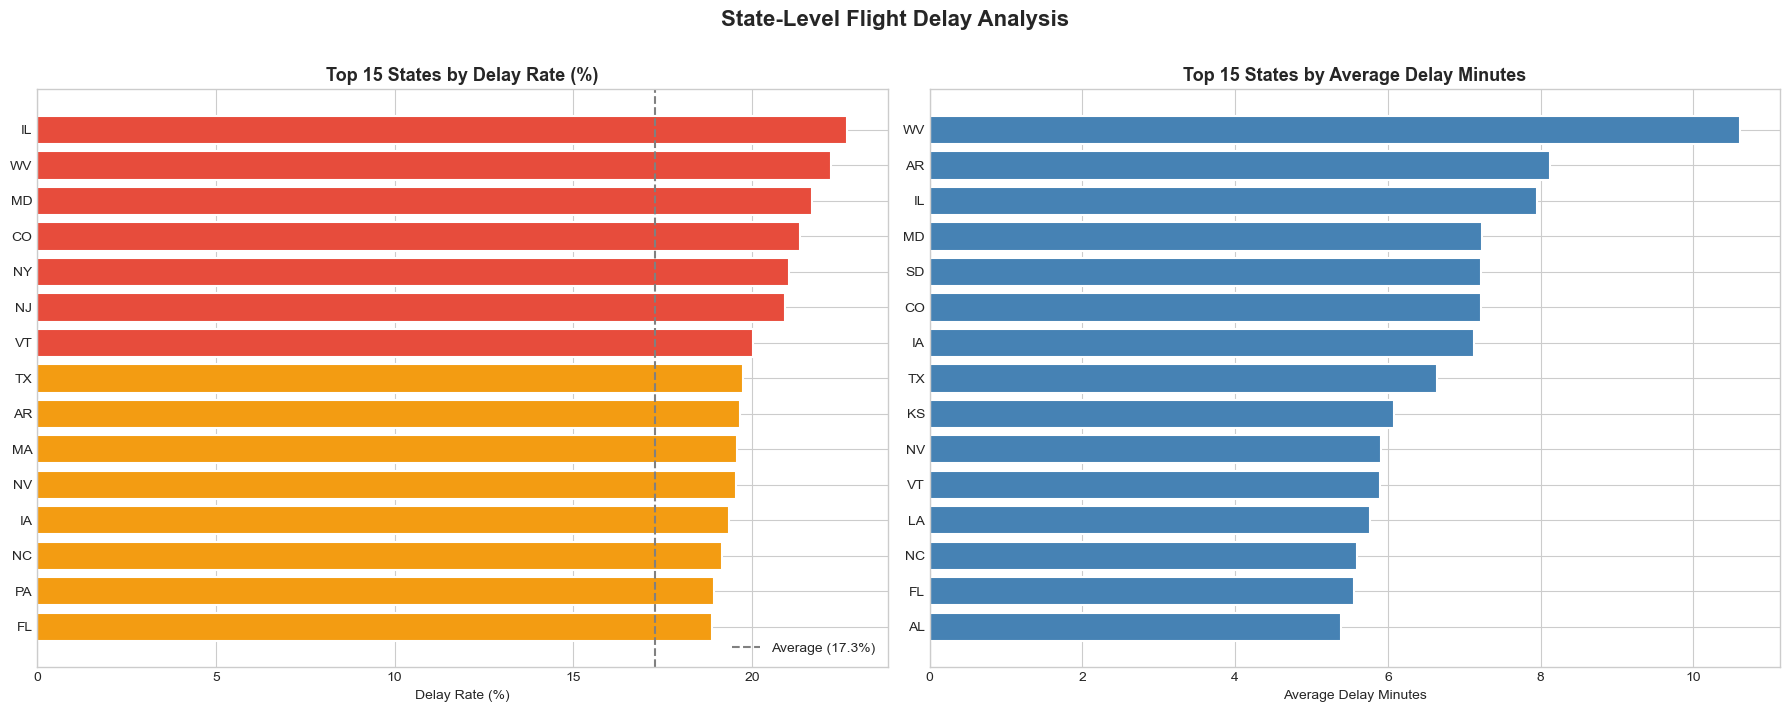


Overall average delay rate: 17.3%

Top 10 states by delay rate:
ORIGIN_STATE  total  delay_rate  avg_delay
          IL 370549   22.661510   7.947702
          WV   2326   22.226999  10.603611
          MD  84546   21.686419   7.229828
          CO 212735   21.346276   7.213735
          NY 238531   21.043386   4.040028
          NJ 104973   20.920618   4.812323
          VT   2889   20.041537   5.900312
          TX 618298   19.757463   6.646769
          AR  21973   19.665043   8.125245
          MA 106603   19.582001   4.299560


In [ ]:
# ── EDA Extension 6: State-Level Analysis ─────────────────────────────────────

# Join state info
flights_state = flights.merge(
    airports[['IATA_CODE', 'STATE']].rename(
        columns={'IATA_CODE': 'ORIGIN_AIRPORT', 'STATE': 'ORIGIN_STATE'}
    ),
    on='ORIGIN_AIRPORT', how='left'
)


flights_state = flights_state[flights_state['CANCELLED'] == 0].copy()
flights_state['ARRIVAL_DELAY'] = flights_state['ARRIVAL_DELAY'].fillna(0)
flights_state['DELAYED'] = (flights_state['ARRIVAL_DELAY'] > 15).astype(int)


state_stats = flights_state.groupby('ORIGIN_STATE').agg(
    total=('DELAYED', 'count'),
    delayed=('DELAYED', 'sum'),
    avg_delay=('ARRIVAL_DELAY', 'mean')
).reset_index()
state_stats = state_stats[state_stats['total'] >= 1000]
state_stats['delay_rate'] = state_stats['delayed'] / state_stats['total'] * 100

avg_rate = state_stats['delay_rate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 15 by delay rate
top15 = state_stats.sort_values('delay_rate', ascending=False).head(15)
colors_bar = ['#e74c3c' if r > 20 else '#f39c12' if r > avg_rate 
              else '#2ecc71' for r in top15['delay_rate']]
axes[0].barh(top15['ORIGIN_STATE'][::-1], 
             top15['delay_rate'][::-1],
             color=colors_bar[::-1], edgecolor='white', linewidth=1.5)
axes[0].axvline(x=avg_rate, color='gray', linestyle='--', 
                linewidth=1.5, label=f'Average ({avg_rate:.1f}%)')
axes[0].set_title('Top 15 States by Delay Rate (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delay Rate (%)')
axes[0].legend()

# Top 15 by avg delay minutes
top15_avg = state_stats.sort_values('avg_delay', ascending=False).head(15)
axes[1].barh(top15_avg['ORIGIN_STATE'][::-1],
             top15_avg['avg_delay'][::-1],
             color='steelblue', edgecolor='white', linewidth=1.5)
axes[1].set_title('Top 15 States by Average Delay Minutes', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Delay Minutes')

plt.suptitle('State-Level Flight Delay Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nOverall average delay rate: {avg_rate:.1f}%")
print("\nTop 10 states by delay rate:")
print(state_stats.sort_values('delay_rate', ascending=False)[
    ['ORIGIN_STATE', 'total', 'delay_rate', 'avg_delay']
].head(10).to_string(index=False))

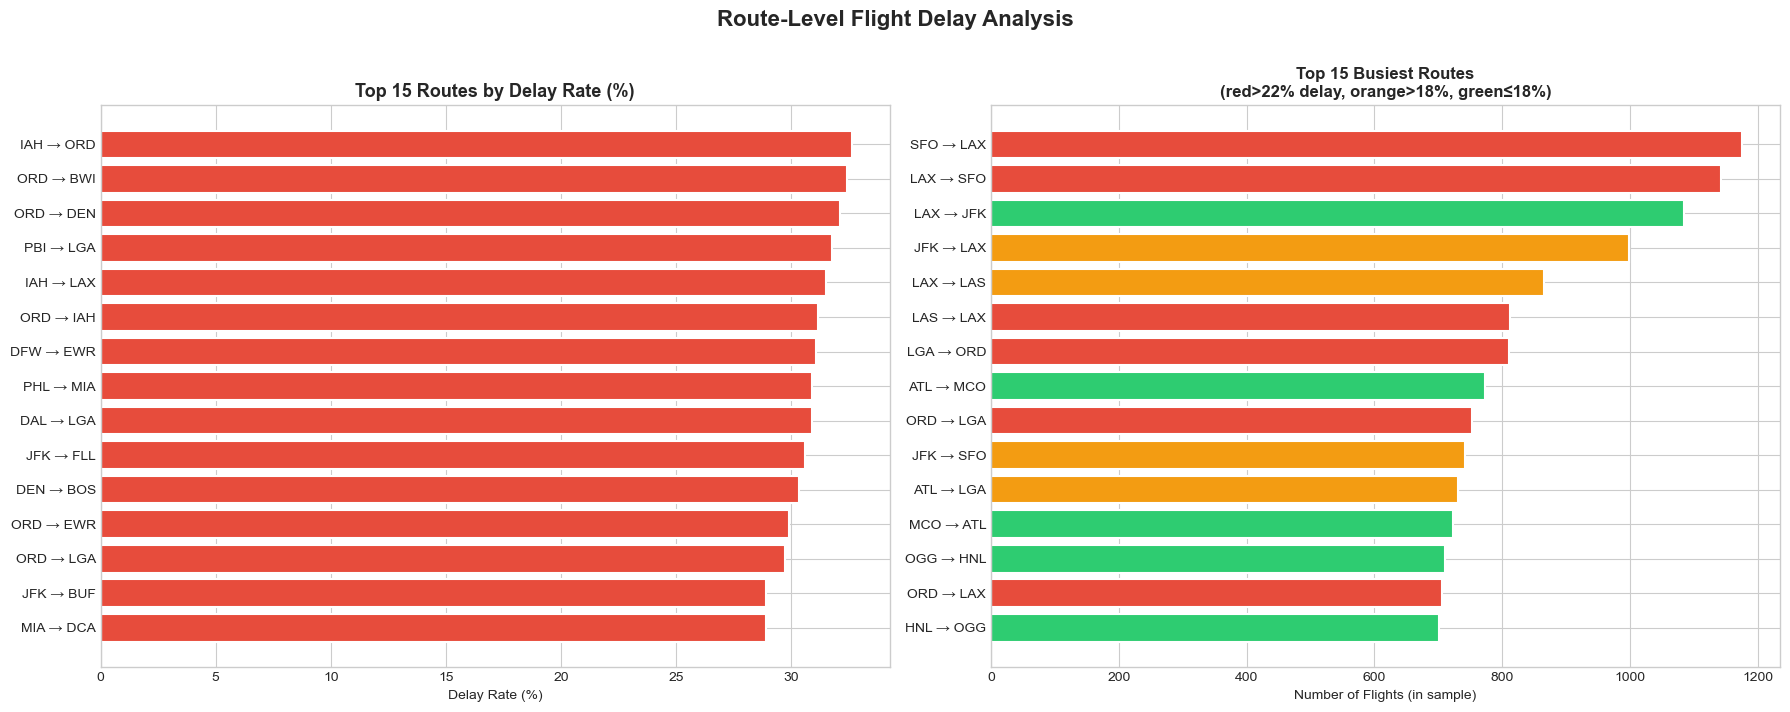


Top 10 most delayed routes:
    ROUTE  total  delay_rate  avg_delay
IAH → ORD    389   32.647815  12.591260
ORD → BWI    219   32.420091  18.913242
ORD → DEN    476   32.142857  18.638655
PBI → LGA    258   31.782946  17.810078
IAH → LAX    368   31.521739  13.804348
ORD → IAH    366   31.147541  14.057377
DFW → EWR    206   31.067961  12.616505
PHL → MIA    207   30.917874  15.768116
DAL → LGA    220   30.909091  16.781818
JFK → FLL    392   30.612245  16.454082


In [ ]:
# ── EDA Extension 7: Route Analysis ───────────────────────────────────────────


sample_routes = flights[flights['CANCELLED'] == 0].sample(
    n=500000, random_state=42
).copy()
sample_routes['ARRIVAL_DELAY'] = sample_routes['ARRIVAL_DELAY'].fillna(0)
sample_routes['DELAYED'] = (sample_routes['ARRIVAL_DELAY'] > 15).astype(int)
sample_routes['ROUTE'] = (sample_routes['ORIGIN_AIRPORT'] + ' → ' + 
                           sample_routes['DESTINATION_AIRPORT'])


route_stats = sample_routes.groupby('ROUTE').agg(
    total=('DELAYED', 'count'),
    delayed=('DELAYED', 'sum'),
    avg_delay=('ARRIVAL_DELAY', 'mean')
).reset_index()
route_stats = route_stats[route_stats['total'] >= 200]
route_stats['delay_rate'] = route_stats['delayed'] / route_stats['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 15 by delay rate
top_routes = route_stats.sort_values('delay_rate', ascending=False).head(15)
axes[0].barh(top_routes['ROUTE'][::-1],
             top_routes['delay_rate'][::-1],
             color='#e74c3c', edgecolor='white', linewidth=1.5)
axes[0].set_title('Top 15 Routes by Delay Rate (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delay Rate (%)')

# Top 15 busiest routes colored by delay rate
top_volume = route_stats.sort_values('total', ascending=False).head(15)
vol_colors = ['#e74c3c' if r > 22 else '#f39c12' if r > 18 
              else '#2ecc71' for r in top_volume['delay_rate']]
axes[1].barh(top_volume['ROUTE'][::-1],
             top_volume['total'][::-1],
             color=vol_colors[::-1], edgecolor='white', linewidth=1.5)
axes[1].set_title('Top 15 Busiest Routes\n(red>22% delay, orange>18%, green≤18%)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Flights (in sample)')

plt.suptitle('Route-Level Flight Delay Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nTop 10 most delayed routes:")
print(route_stats.sort_values('delay_rate', ascending=False)[
    ['ROUTE', 'total', 'delay_rate', 'avg_delay']
].head(10).to_string(index=False))

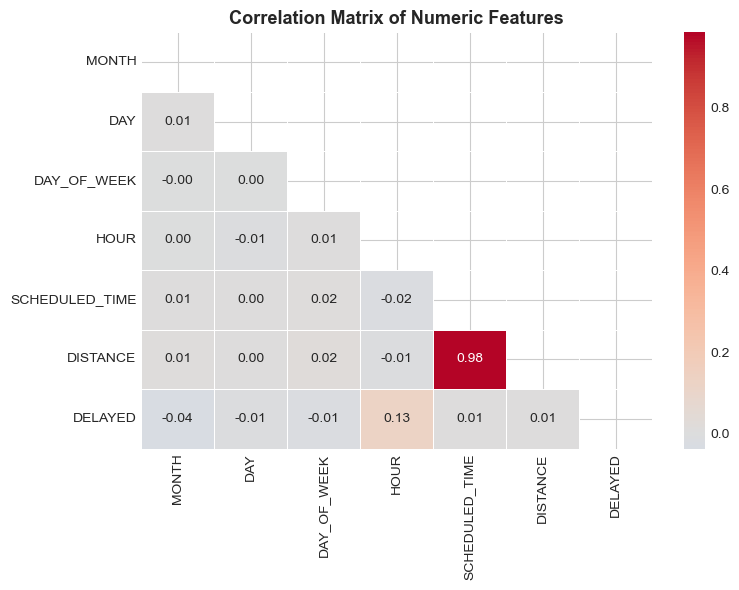

In [24]:
# ── 4.7 Correlation heatmap of numeric features ───────────────────────────────
numeric_cols = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'HOUR',
                'SCHEDULED_TIME', 'DISTANCE', 'DELAYED']
numeric_cols = [c for c in numeric_cols if c in df.columns]

plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, center=0, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

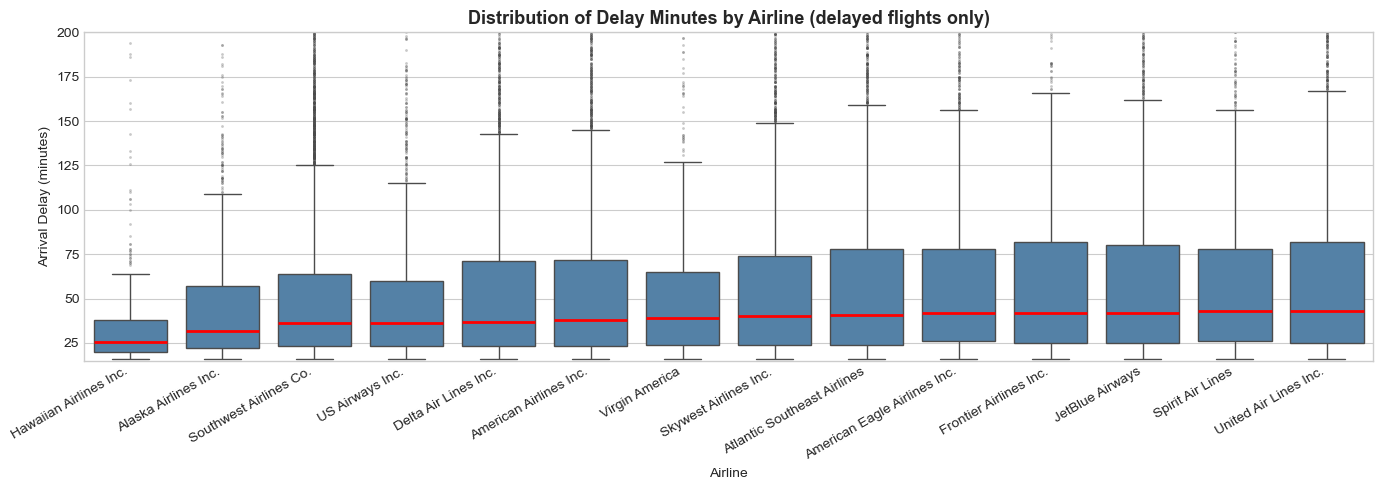

In [ ]:
# ── 4.8 Box plot: Delay minutes by airline ────────────────────────────────────
delayed_flights = flights[flights['ARRIVAL_DELAY'] > 15].sample(50000, random_state=SEED)
delayed_flights = delayed_flights.merge(
    airlines.rename(columns={'IATA_CODE': 'CODE', 'AIRLINE': 'AIRLINE_NAME'}),
    left_on='AIRLINE', right_on='CODE', how='left'
)


order = (delayed_flights.groupby('AIRLINE_NAME')['ARRIVAL_DELAY']
                        .median().sort_values().index.tolist())

plt.figure(figsize=(14, 5))
sns.boxplot(data=delayed_flights, x='AIRLINE_NAME', y='ARRIVAL_DELAY',
            order=order, color='steelblue',
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='.', alpha=0.3, markersize=2),
            whis=1.5)
plt.title('Distribution of Delay Minutes by Airline (delayed flights only)',
          fontsize=13, fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Arrival Delay (minutes)')
plt.xticks(rotation=30, ha='right')
plt.ylim(15, 200)
plt.tight_layout()
plt.show()

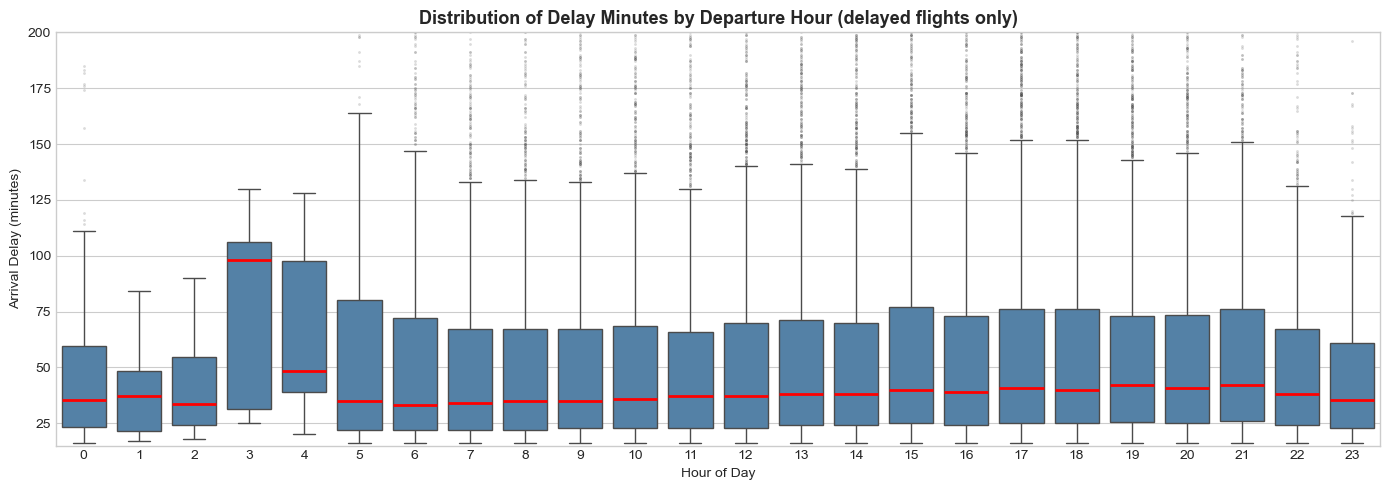

Observation: Evening flights not only delay more often, they delay longer.


In [26]:
# ── 4.9 Box plot: Delay minutes by departure hour ─────────────────────────────
delayed_flights['HOUR'] = delayed_flights['SCHEDULED_DEPARTURE'] // 100

plt.figure(figsize=(14, 5))
sns.boxplot(data=delayed_flights, x='HOUR', y='ARRIVAL_DELAY',
            color='steelblue',
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='.', alpha=0.2, markersize=2),
            whis=1.5)
plt.title('Distribution of Delay Minutes by Departure Hour (delayed flights only)',
          fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Arrival Delay (minutes)')
plt.ylim(15, 200)
plt.tight_layout()
plt.show()
print('Observation: Evening flights not only delay more often, they delay longer.')

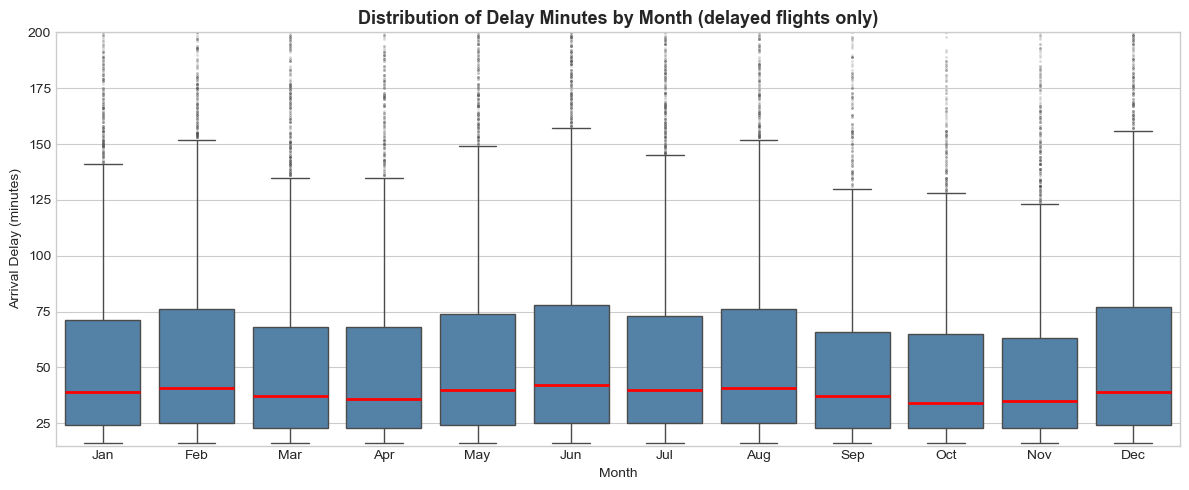

In [27]:
# ── 4.10 Box plot: Delay minutes by month ─────────────────────────────────────
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
delayed_flights['MONTH_NAME'] = delayed_flights['MONTH'].map(month_names)
month_order = list(month_names.values())   # Jan → Dec 顺序

plt.figure(figsize=(12, 5))
sns.boxplot(data=delayed_flights, x='MONTH_NAME', y='ARRIVAL_DELAY',
            order=month_order, color='steelblue',
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='.', alpha=0.2, markersize=2),
            whis=1.5)
plt.title('Distribution of Delay Minutes by Month (delayed flights only)',
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Arrival Delay (minutes)')
plt.ylim(15, 200)
plt.tight_layout()
plt.show()